In [2]:
# General imports
from netsim.netSimPy import *
from netsim.netSimPy.common.evaluators import NetworkEvaluator
from netsim.netSimPy.common.allocators import alphaBalancing

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
import itertools

# available_bands = [["C", "L", "S", "E"], ["E", "S", "L", "C"]]
# simulators = {}
# for alpha in range(0,11,1):
N_EVALUATIONS = 1000000

available_bands = ["C", "S", "L", "E"]
traffics = [50000, 75000, 100000, 125000, 150000, 175000, 200000]
alphas = [1.0]
# alphas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.2, 0.1, 1]
simulators = {}


for alpha in alphas:
    for bands1 in list(itertools.permutations(available_bands)):
        for bands2 in list(itertools.permutations(available_bands)):
            if (
                list(bands1) == ["C", "S", "L", "E"]
                or list(bands1) == ["E", "L", "S", "C"]
            ) and (
                list(bands2) == ["C", "S", "L", "E"]
                or list(bands2) == ["E", "L", "S", "C"]
            ):
                # if list(bands1) == list(bands2):
                #     continue
                allocator = alphaBalancing(1, [alpha, 1], [bands1, bands2])
                network = Network(
                    networkFileName="../../../networks/nsfnet/network.json",
                    pathsFileName="../../../networks/nsfnet/routes.json",
                    bitrateFilename="../../../networks/nsfnet/bitrates_4_bands.json",
                )

                generator = EventsGenerator(10000)
                sim_args1 = dict(
                    eventsGenerator=generator,
                    network=network,
                    allocator=allocator,
                )
                simulator = NetworkSimulator(**sim_args1)
                name = "".join(bands1) + "_" + "".join(bands2) + "_" + f"{alpha}"
                for traffic in traffics:
                    callback = NetworkEvaluator(f"{name}_{int(traffic/100)}")
                    simulator.reset()
                    simulator.setLambda(traffic)
                    print(f"Running simulation for {name} with lambda: {traffic/100}")
                    simulator.run(N_EVALUATIONS, callback)
                    print("\n")

Running simulation for CSLE_CSLE_1.0 with lambda: 500.0
Blocking probability: 0.0


Running simulation for CSLE_CSLE_1.0 with lambda: 750.0
Blocking probability: 0.0


Running simulation for CSLE_CSLE_1.0 with lambda: 1000.0
Blocking probability: 0.000388


Running simulation for CSLE_CSLE_1.0 with lambda: 1250.0
Blocking probability: 0.00396


Running simulation for CSLE_CSLE_1.0 with lambda: 1500.0
Blocking probability: 0.008375


Running simulation for CSLE_CSLE_1.0 with lambda: 1750.0
Blocking probability: 0.01559


Running simulation for CSLE_CSLE_1.0 with lambda: 2000.0
Blocking probability: 0.024425


Running simulation for CSLE_ELSC_1.0 with lambda: 500.0
Blocking probability: 0.0


Running simulation for CSLE_ELSC_1.0 with lambda: 750.0
Blocking probability: 0.0


Running simulation for CSLE_ELSC_1.0 with lambda: 1000.0
Blocking probability: 0.000388


Running simulation for CSLE_ELSC_1.0 with lambda: 1250.0
Blocking probability: 0.00396


Running simulation for CSLE_ELSC_1.0 

In [3]:
from typing import Any
import pandas as pd
import ast
from pathlib import Path
import glob


def read_csv(path: Path):
    # Read the CSV, skip the first comment line
    df = pd.read_csv(path.resolve(), comment="#")
    # Take the first row and convert it to a dict (columns become keys)
    row_dict = df.iloc[0].to_dict()
    # Try to parse each value that looks like a dictionary
    for key, value in row_dict.items():
        if isinstance(value, str) and value.strip().startswith(("{", "[")):
            try:
                row_dict[key] = ast.literal_eval(value)
            except Exception:
                pass  # Leave as-is if not safely parsable
    return row_dict

In [4]:
results: dict[str, list[dict[str, Any]]] = {}
loads = {}
orders = {}

for file in glob.glob("./*.csv"):
    path = Path(file)
    name = path.name
    order0, order1, alpha, load = name.split("net.evaluations")[0].split("_")

    if not alpha in results:
        results[alpha] = {}
    try:
        csv = read_csv(path)
        order = f"{order0}-{order1}"
        csv["load"] = load
        if order not in results[alpha]:
            results[alpha][order] = []
        results[alpha][order].append(csv)
    except Exception:
        pass

0.9 {'SECL-CSEL': [{'steps': 1000000, 'blockedEvents': 0, 'attendedByRouteIndex': {0: 1000000}, 'totalAttendedByBand': {'C': 27249, 'S': 942008, 'L': 4918, 'E': 25825}, 'totalAttended': 1000000, 'attendedByModulation': {'8-QAM': 447991, 'QPSK': 195994, '16-QAM': 225641, '32-QAM': 65752, '64-QAM': 44063, 'BPSK': 20559}, 'blockedBitRateByBitRate': {}, 'totalBitRate': 310198570, 'bitRateByBand': {'C': 25593600, 'S': 254327870, 'L': 4873000, 'E': 25404100}, 'load': '1000'}, {'steps': 1000000, 'blockedEvents': 5938, 'attendedByRouteIndex': {0: 994062}, 'totalAttendedByBand': {'C': 32974, 'S': 907374, 'L': 24591, 'E': 29123}, 'totalAttended': 994062, 'attendedByModulation': {'8-QAM': 453101, 'QPSK': 185503, '16-QAM': 225112, '32-QAM': 65749, '64-QAM': 44063, 'BPSK': 20534}, 'blockedBitRateByBitRate': {1000: 5903000, 400: 14000}, 'totalBitRate': 304281570, 'bitRateByBand': {'C': 29631700, 'S': 223375170, 'L': 23791200, 'E': 27483500}, 'load': '1500'}, {'steps': 1000000, 'blockedEvents': 0, 'a

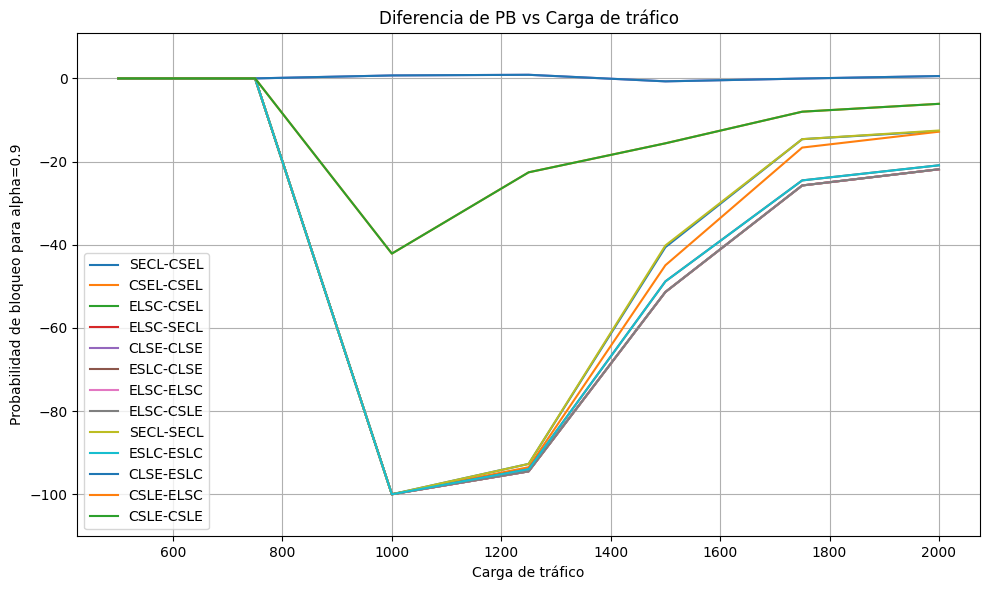

0.2 {'ESLC-CLSE': [{'steps': 1000000, 'blockedEvents': 89, 'attendedByRouteIndex': {0: 999911}, 'totalAttendedByBand': {'C': 110209, 'S': 244654, 'L': 63784, 'E': 581264}, 'totalAttended': 999911, 'attendedByModulation': {'BPSK': 313440, 'QPSK': 285466, '8-QAM': 257690, '16-QAM': 99722, '32-QAM': 29685, '64-QAM': 13908}, 'blockedBitRateByBitRate': {1000: 88000, 400: 400}, 'totalBitRate': 310110170, 'bitRateByBand': {'C': 67122400, 'S': 77312890, 'L': 53908150, 'E': 111766730}, 'load': '1000'}, {'steps': 1000000, 'blockedEvents': 9135, 'attendedByRouteIndex': {0: 990865}, 'totalAttendedByBand': {'C': 174755, 'S': 247600, 'L': 87203, 'E': 481307}, 'totalAttended': 990865, 'attendedByModulation': {'BPSK': 266185, 'QPSK': 243892, '8-QAM': 291468, '16-QAM': 120285, '32-QAM': 43315, '64-QAM': 25720}, 'blockedBitRateByBitRate': {1000: 8981000, 400: 61600}, 'totalBitRate': 301155970, 'bitRateByBand': {'C': 81287840, 'S': 77005570, 'L': 62900390, 'E': 79962170}, 'load': '1500'}, {'steps': 10000

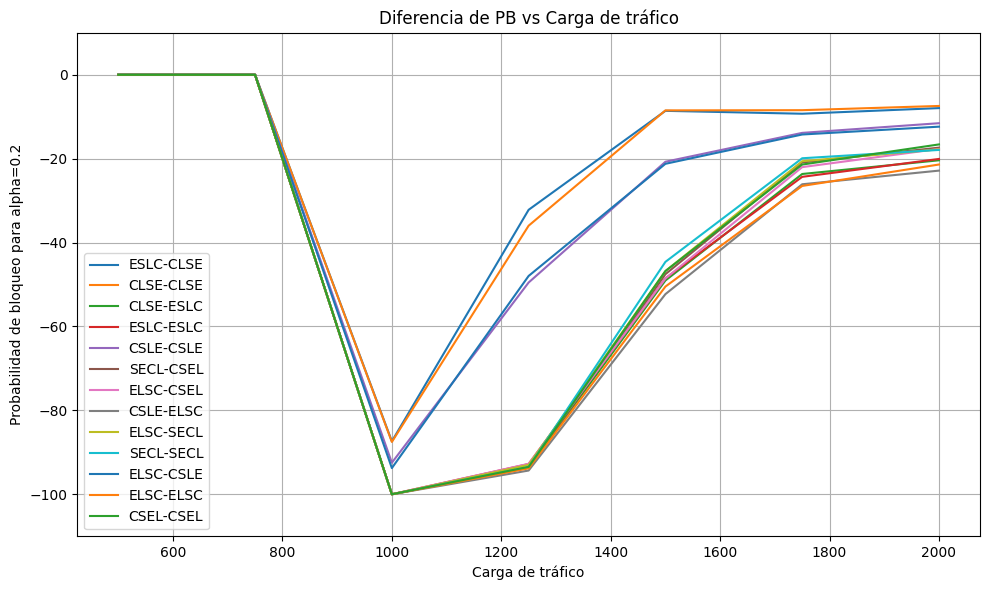

0.8 {'CLSE-ESLC': [{'steps': 1000000, 'blockedEvents': 5184, 'attendedByRouteIndex': {0: 994816}, 'totalAttendedByBand': {'C': 836252, 'S': 45892, 'L': 107139, 'E': 5533}, 'totalAttended': 994816, 'attendedByModulation': {'8-QAM': 520582, '32-QAM': 118401, '16-QAM': 234779, '64-QAM': 46555, 'QPSK': 70404, 'BPSK': 4095}, 'blockedBitRateByBitRate': {1000: 5149000, 400: 14000}, 'totalBitRate': 305035570, 'bitRateByBand': {'C': 173675150, 'S': 44237500, 'L': 82077420, 'E': 5045500}, 'load': '1250'}, {'steps': 1000000, 'blockedEvents': 17230, 'attendedByRouteIndex': {0: 982770}, 'totalAttendedByBand': {'C': 778171, 'S': 56200, 'L': 134198, 'E': 14201}, 'totalAttended': 982770, 'attendedByModulation': {'8-QAM': 503687, '32-QAM': 117516, '16-QAM': 227819, '64-QAM': 49990, 'QPSK': 73022, 'BPSK': 10736}, 'blockedBitRateByBitRate': {1000: 16712000, 400: 207200}, 'totalBitRate': 293279370, 'bitRateByBand': {'C': 146113420, 'S': 52833880, 'L': 81009470, 'E': 13322600}, 'load': '1750'}, {'steps': 1

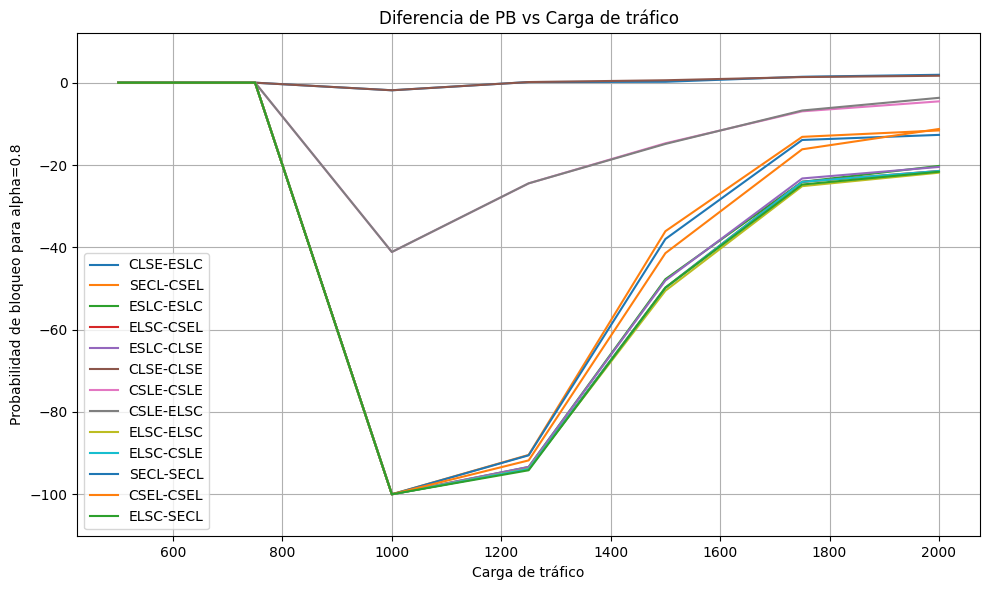

0.1 {'ELSC-CSLE': [{'steps': 1000000, 'blockedEvents': 154, 'attendedByRouteIndex': {0: 999846}, 'totalAttendedByBand': {'C': 200019, 'S': 133432, 'L': 209667, 'E': 456728}, 'totalAttended': 999846, 'attendedByModulation': {'BPSK': 252442, '8-QAM': 382539, 'QPSK': 155790, '16-QAM': 131384, '32-QAM': 53168, '64-QAM': 24523}, 'blockedBitRateByBitRate': {1000: 154000}, 'totalBitRate': 310044570, 'bitRateByBand': {'C': 104643420, 'S': 88438660, 'L': 47518530, 'E': 69443960}, 'load': '1000'}, {'steps': 1000000, 'blockedEvents': 8071, 'attendedByRouteIndex': {0: 991929}, 'totalAttendedByBand': {'C': 282128, 'S': 162537, 'L': 173662, 'E': 373602}, 'totalAttended': 991929, 'attendedByModulation': {'BPSK': 208413, '8-QAM': 380597, 'QPSK': 158092, '16-QAM': 145655, '32-QAM': 65637, '64-QAM': 33535}, 'blockedBitRateByBitRate': {1000: 7939000, 400: 52800}, 'totalBitRate': 302206770, 'bitRateByBand': {'C': 112591280, 'S': 90526380, 'L': 46178200, 'E': 52910910}, 'load': '1500'}, {'steps': 1000000, 

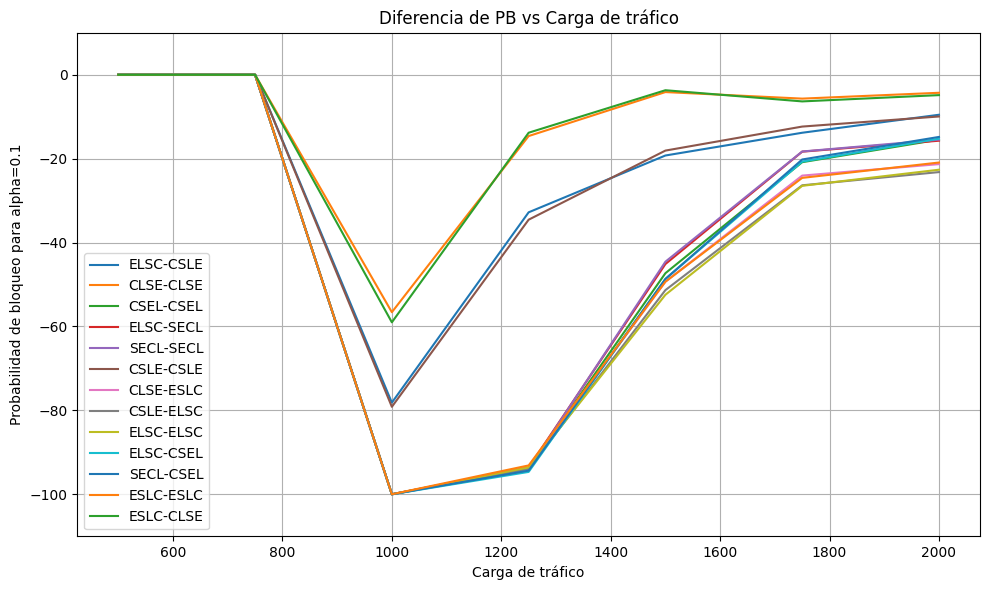

0.7 {'ESLC-ESLC': [{'steps': 1000000, 'blockedEvents': 455, 'attendedByRouteIndex': {0: 999545}, 'totalAttendedByBand': {'C': 9295, 'S': 219556, 'L': 33407, 'E': 737287}, 'totalAttended': 999545, 'attendedByModulation': {'BPSK': 379335, 'QPSK': 356578, '8-QAM': 201256, '16-QAM': 45786, '32-QAM': 15735, '64-QAM': 855}, 'blockedBitRateByBitRate': {1000: 455000}, 'totalBitRate': 309743570, 'bitRateByBand': {'C': 7225600, 'S': 80046580, 'L': 30152000, 'E': 192319390}, 'load': '1250'}, {'steps': 1000000, 'blockedEvents': 13676, 'attendedByRouteIndex': {0: 986324}, 'totalAttendedByBand': {'C': 14558, 'S': 221253, 'L': 40598, 'E': 709915}, 'totalAttended': 986324, 'attendedByModulation': {'BPSK': 362995, 'QPSK': 336039, '8-QAM': 213574, '16-QAM': 55602, '32-QAM': 16102, '64-QAM': 2012}, 'blockedBitRateByBitRate': {1000: 13599000, 400: 30800}, 'totalBitRate': 296568770, 'bitRateByBand': {'C': 13153700, 'S': 73545780, 'L': 36935000, 'E': 172934290}, 'load': '1750'}, {'steps': 1000000, 'blockedE

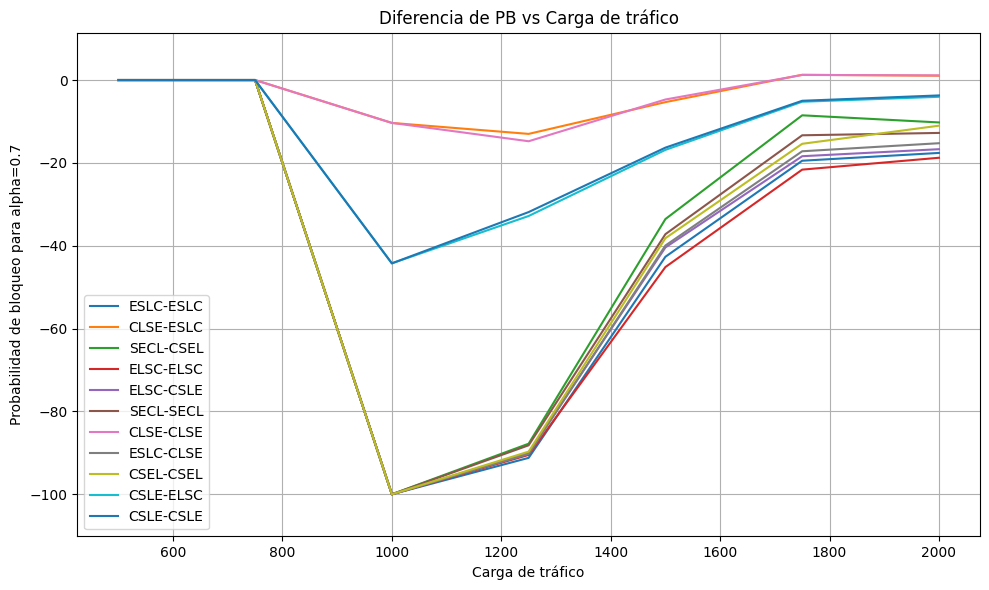

0.3 {'ESLC-CLSE': [{'steps': 1000000, 'blockedEvents': 23245, 'attendedByRouteIndex': {0: 976755}, 'totalAttendedByBand': {'C': 142906, 'S': 248931, 'L': 85040, 'E': 499878}, 'totalAttended': 976755, 'attendedByModulation': {'BPSK': 277790, 'QPSK': 247678, '8-QAM': 273455, '16-QAM': 112345, '32-QAM': 37974, '64-QAM': 27513}, 'blockedBitRateByBitRate': {1000: 22485000, 400: 304000}, 'totalBitRate': 287409570, 'bitRateByBand': {'C': 65410900, 'S': 77899920, 'L': 57515420, 'E': 86583330}, 'load': '2000'}, {'steps': 1000000, 'blockedEvents': 2722, 'attendedByRouteIndex': {0: 997278}, 'totalAttendedByBand': {'C': 92004, 'S': 233607, 'L': 66758, 'E': 604909}, 'totalAttended': 997278, 'attendedByModulation': {'BPSK': 326073, 'QPSK': 292901, '8-QAM': 244320, '16-QAM': 92275, '32-QAM': 27720, '64-QAM': 13989}, 'blockedBitRateByBitRate': {1000: 2689000, 400: 13200}, 'totalBitRate': 307496370, 'bitRateByBand': {'C': 53458980, 'S': 80855520, 'L': 50272460, 'E': 122909410}, 'load': '1250'}, {'steps

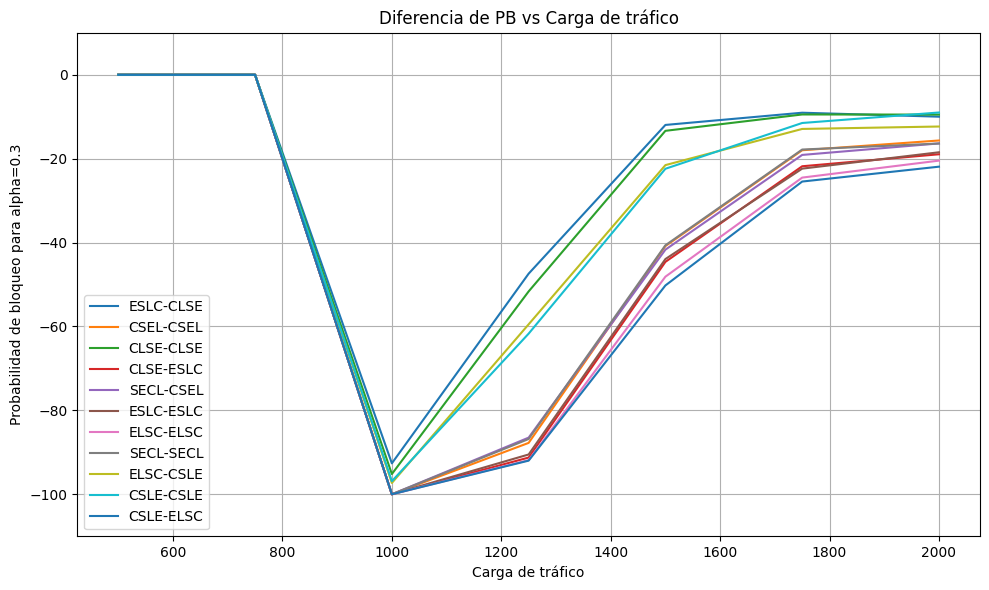

0.4 {'ELSC-ELSC': [{'steps': 1000000, 'blockedEvents': 523, 'attendedByRouteIndex': {0: 999477}, 'totalAttendedByBand': {'C': 33941, 'S': 84398, 'L': 223202, 'E': 657936}, 'totalAttended': 999477, 'attendedByModulation': {'BPSK': 344091, '8-QAM': 363368, 'QPSK': 192855, '16-QAM': 63390, '32-QAM': 22736, '64-QAM': 13037}, 'blockedBitRateByBitRate': {1000: 523000}, 'totalBitRate': 309675570, 'bitRateByBand': {'C': 24593600, 'S': 61841840, 'L': 69888980, 'E': 153351150}, 'load': '1250'}, {'steps': 1000000, 'blockedEvents': 13471, 'attendedByRouteIndex': {0: 986529}, 'totalAttendedByBand': {'C': 42228, 'S': 92225, 'L': 234924, 'E': 617152}, 'totalAttended': 986529, 'attendedByModulation': {'BPSK': 325856, '8-QAM': 347218, 'QPSK': 183669, '16-QAM': 82779, '32-QAM': 32066, '64-QAM': 14941}, 'blockedBitRateByBitRate': {1000: 13437000, 400: 13600}, 'totalBitRate': 296747970, 'bitRateByBand': {'C': 26950320, 'S': 64191200, 'L': 69959160, 'E': 135647290}, 'load': '1750'}, {'steps': 1000000, 'blo

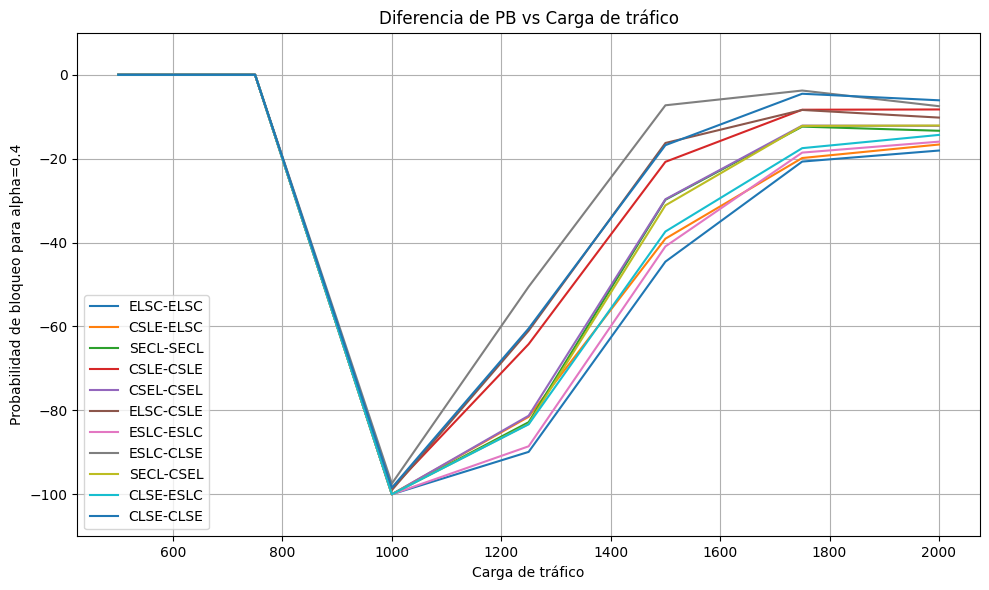

0.6 {'CSLE-CSLE': [{'steps': 1000000, 'blockedEvents': 0, 'attendedByRouteIndex': {0: 1000000}, 'totalAttendedByBand': {'C': 904060, 'S': 94578, 'L': 1362, 'E': 0}, 'totalAttended': 1000000, 'attendedByModulation': {'8-QAM': 510334, '32-QAM': 114446, '16-QAM': 233436, '64-QAM': 44064, 'QPSK': 97720}, 'blockedBitRateByBitRate': {}, 'totalBitRate': 310198570, 'bitRateByBand': {'C': 229561930, 'S': 80009340, 'L': 627300, 'E': 0}, 'load': '500'}, {'steps': 1000000, 'blockedEvents': 278, 'attendedByRouteIndex': {0: 999722}, 'totalAttendedByBand': {'C': 808175, 'S': 149011, 'L': 35139, 'E': 7397}, 'totalAttended': 999722, 'attendedByModulation': {'8-QAM': 510604, '32-QAM': 109779, '16-QAM': 230801, '64-QAM': 44104, 'QPSK': 103493, 'BPSK': 941}, 'blockedBitRateByBitRate': {1000: 278000}, 'totalBitRate': 309920570, 'bitRateByBand': {'C': 168210830, 'S': 107830240, 'L': 28944300, 'E': 4935200}, 'load': '1000'}, {'steps': 1000000, 'blockedEvents': 8245, 'attendedByRouteIndex': {0: 991755}, 'tota

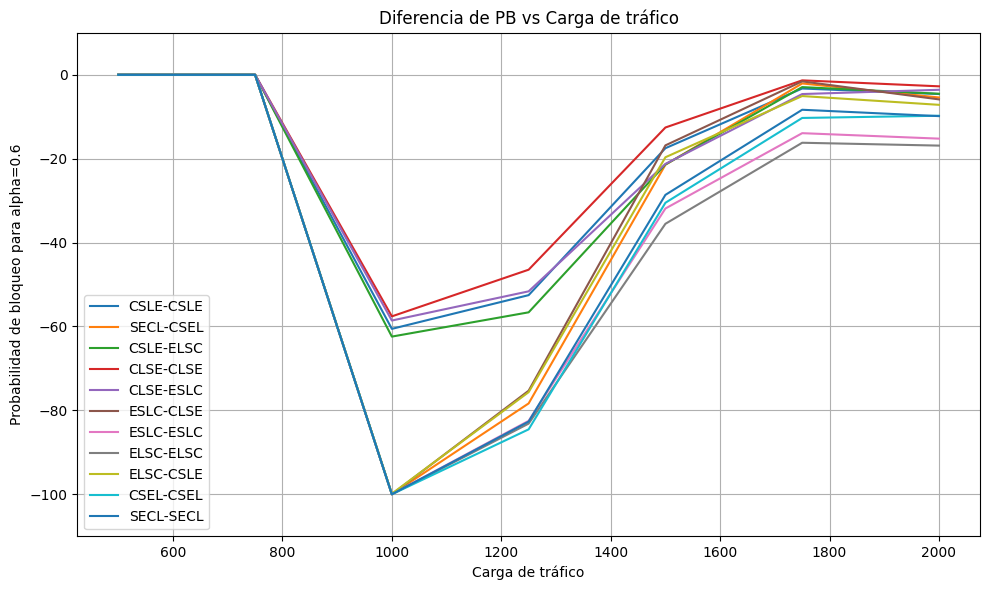

1.0 {'CLSE-CLSE': [{'steps': 1000000, 'blockedEvents': 0, 'attendedByRouteIndex': {0: 1000000}, 'totalAttendedByBand': {'C': 895935, 'S': 17633, 'L': 86432, 'E': 0}, 'totalAttended': 1000000, 'attendedByModulation': {'8-QAM': 528318, '32-QAM': 120077, '16-QAM': 238914, '64-QAM': 44321, 'QPSK': 68370}, 'blockedBitRateByBitRate': {}, 'totalBitRate': 310198570, 'bitRateByBand': {'C': 213412770, 'S': 17520200, 'L': 79265600, 'E': 0}, 'load': '750'}, {'steps': 1000000, 'blockedEvents': 9994, 'attendedByRouteIndex': {0: 990006}, 'totalAttendedByBand': {'C': 816943, 'S': 51126, 'L': 111765, 'E': 10172}, 'totalAttended': 990006, 'attendedByModulation': {'8-QAM': 510900, '32-QAM': 118924, '16-QAM': 231262, '64-QAM': 48400, 'QPSK': 71717, 'BPSK': 8803}, 'blockedBitRateByBitRate': {1000: 9812000, 400: 72800}, 'totalBitRate': 300313770, 'bitRateByBand': {'C': 160785670, 'S': 49243200, 'L': 80118300, 'E': 10166600}, 'load': '1500'}, {'steps': 1000000, 'blockedEvents': 705, 'attendedByRouteIndex': {

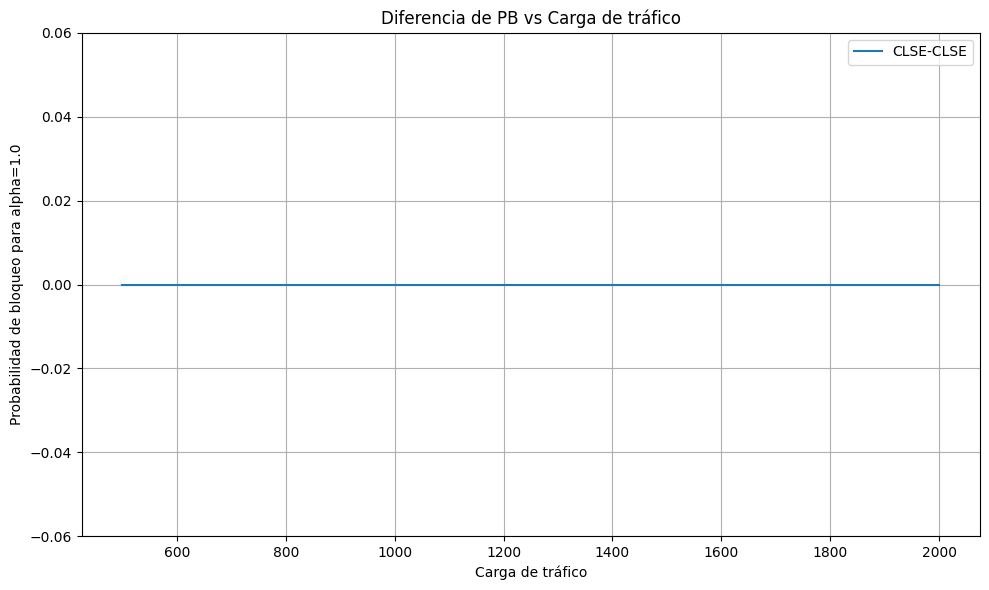

0.5 {'SECL-SECL': [{'steps': 1000000, 'blockedEvents': 23041, 'attendedByRouteIndex': {0: 976959}, 'totalAttendedByBand': {'C': 43176, 'S': 780142, 'L': 44464, 'E': 109177}, 'totalAttended': 976959, 'attendedByModulation': {'8-QAM': 437164, 'QPSK': 189031, '16-QAM': 202840, '32-QAM': 59407, '64-QAM': 37990, 'BPSK': 50527}, 'blockedBitRateByBitRate': {1000: 22753000, 400: 115200}, 'totalBitRate': 287330370, 'bitRateByBand': {'C': 29401800, 'S': 164789110, 'L': 36765400, 'E': 56374060}, 'load': '2000'}, {'steps': 1000000, 'blockedEvents': 935, 'attendedByRouteIndex': {0: 999065}, 'totalAttendedByBand': {'C': 36626, 'S': 857001, 'L': 34458, 'E': 70980}, 'totalAttended': 999065, 'attendedByModulation': {'8-QAM': 437634, 'QPSK': 192334, '16-QAM': 224113, '32-QAM': 63693, '64-QAM': 39382, 'BPSK': 41909}, 'blockedBitRateByBitRate': {1000: 934000, 400: 400}, 'totalBitRate': 309264170, 'bitRateByBand': {'C': 29682200, 'S': 201325350, 'L': 30122100, 'E': 48134520}, 'load': '1250'}, {'steps': 100

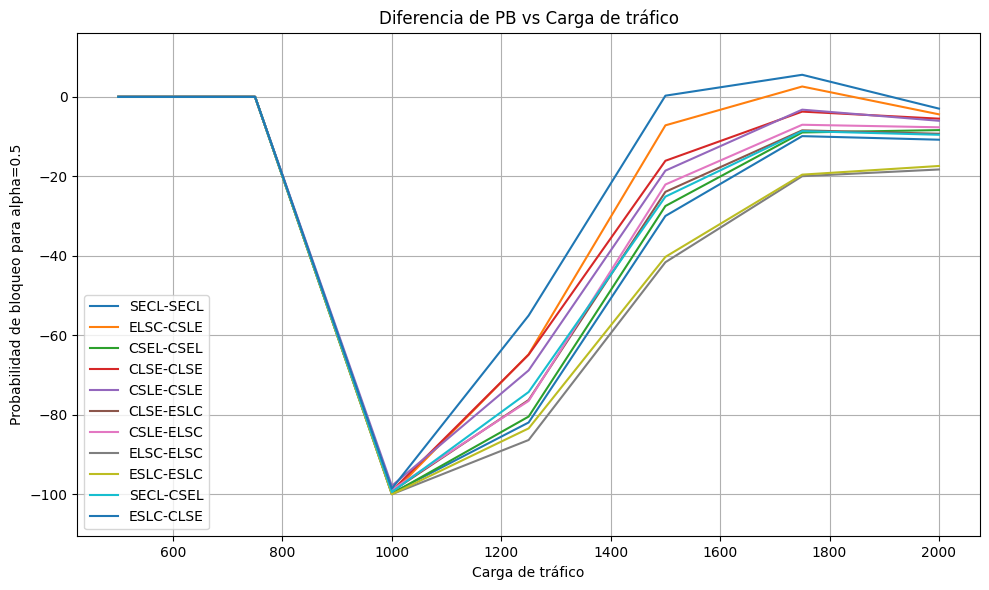

In [ ]:
# Diferencia porcentual
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    # key = "0.3"
    # data = results["0.3"]
    if key == "1.0":
        continue
    print(key, data)
    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
            continue
        valor_clse = results["1.0"]["CLSE-CLSE"]
        pb = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in valor_clse
        ]
        pb_ordenados = sorted(pb, key=lambda p: p[0])
        # if order_key == "ESLC-ESLC":
        #     continue
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        for ind, ((pb_x, pb_y), (pa_x, pa_y)) in enumerate(
            zip(pb_ordenados, pares_ordenados)
        ):
            if pb_y == 0:
                pares_ordenados[ind] = (pa_x, 0)
            else:
                pares_ordenados[ind] = (pa_x, (pa_y - pb_y) * 100 / pb_y)
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Diferencia de PB vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Revision de balanceo de bandas


In [23]:
load = "1000"
bands_capacity = {"C": 344, "L": 480, "S": 760, "E": 1136}
idata = {}

for key, data in results.items():
    idata[key] = {}
    # key = "0.3"
    # data = results["0.3"]
    for order_key, order_data in data.items():
        # if key != "0.3":
        #     continue
        for val in order_data:
            if load == val["load"]:
                # val["totalAttendedByBand"] = {'C': 32757, 'S': 922599, 'L': 16531, 'E': 27735}
                idata[key][order_key] = val["totalAttendedByBand"]
                # print(idata)
                for key_value, value in val["totalAttendedByBand"].items():
                    idata[key][order_key][key_value] = value / bands_capacity[key_value]
        # print(f"Resultados para order_key={order_key} y order_data={order_data}:")
print(idata)

{'0.9': {'SECL-CSEL': {'C': 79.21220930232558, 'S': 1239.4842105263158, 'L': 10.245833333333334, 'E': 22.733274647887324}, 'CSEL-CSEL': {'C': 2522.9447674418607, 'S': 143.70394736842104, 'L': 23.3, 'E': 10.306338028169014}, 'ELSC-CSEL': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'ELSC-SECL': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'CLSE-CLSE': {'C': 2522.9447674418607, 'S': 45.7828947368421, 'L': 200.16875, 'E': 0.4586267605633803}, 'ESLC-CLSE': {'C': 0.8197674418604651, 'S': 288.6197368421053, 'L': 40.0375, 'E': 670.0255281690141}, 'ELSC-ELSC': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'ELSC-CSLE': {'C': 0.9273255813953488, 'S': 37.7, 'L': 437.25, 'E': 670.0255281690141}, 'SECL-SECL': {'C': 79.21220930232558, 'S': 1239.4842105263158, 'L': 10.245833333333334, 'E': 22.733274647887324}, 'ESLC-ESLC': {'C': 0.8197674418604651, 'S': 288.6197368421053, 'L': 40.0375, 'E': 670.0255281690141}, 'C

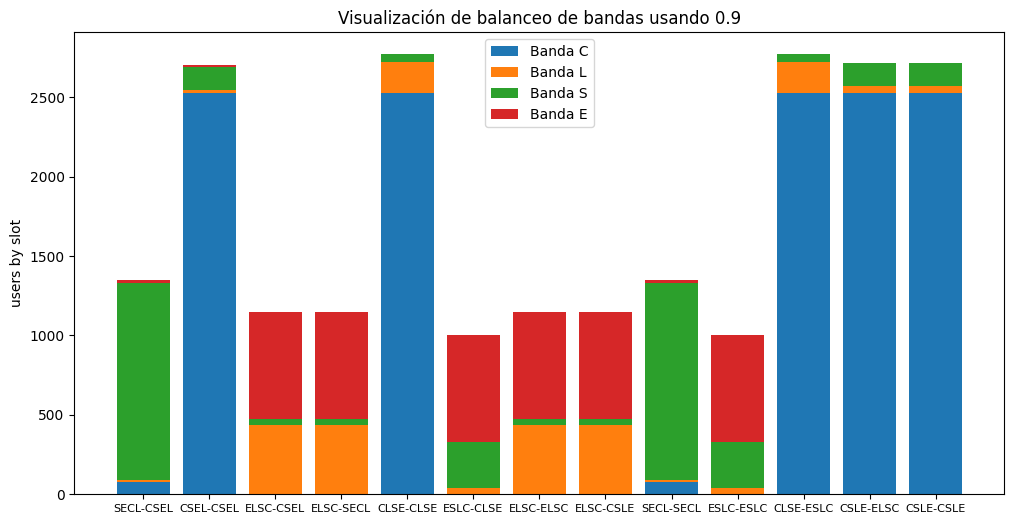

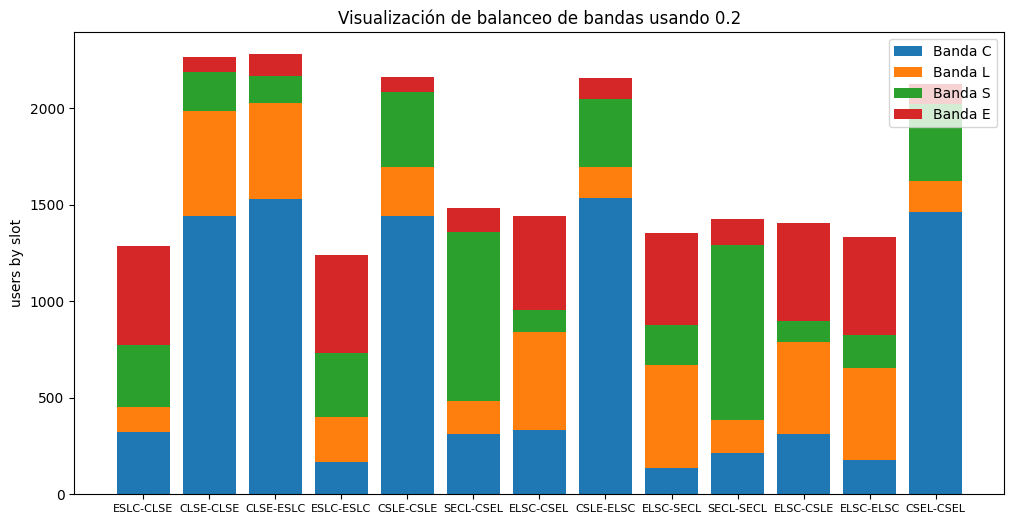

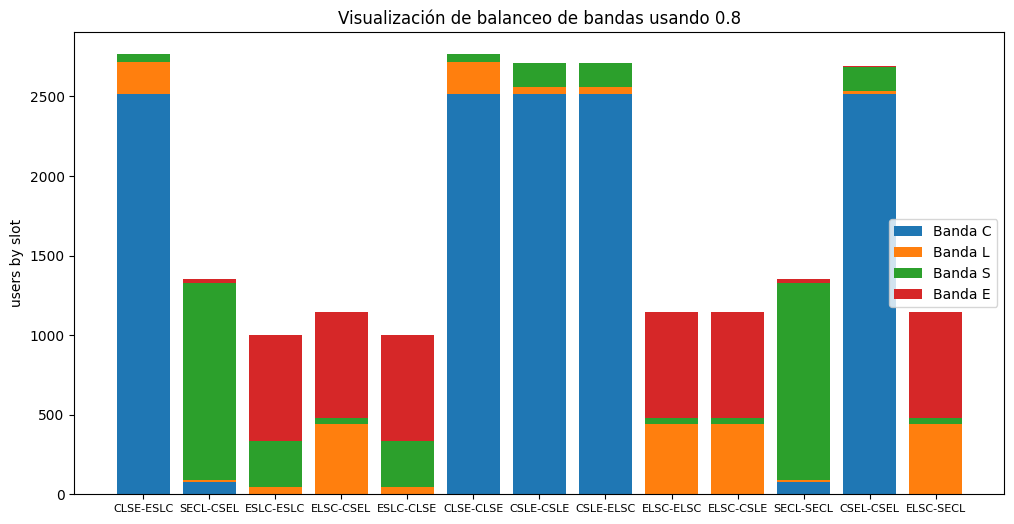

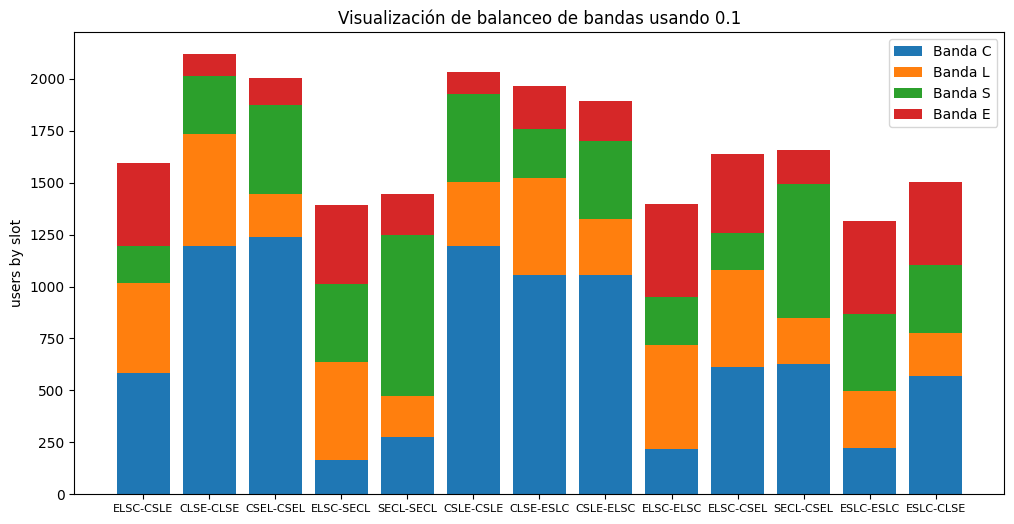

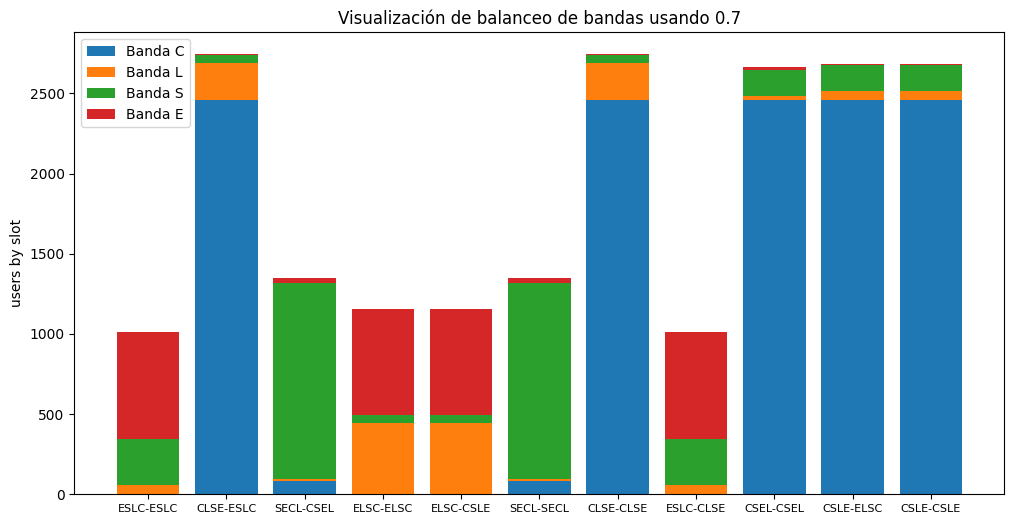

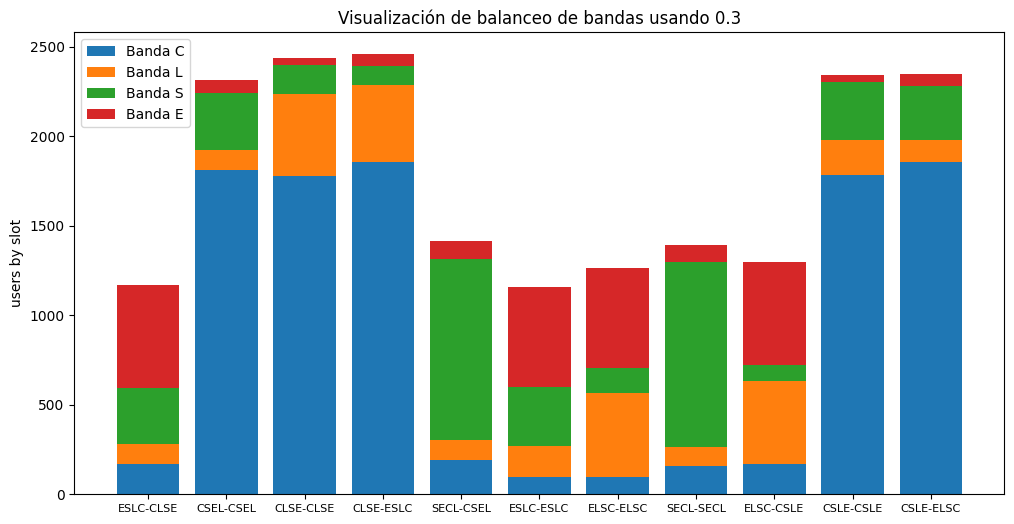

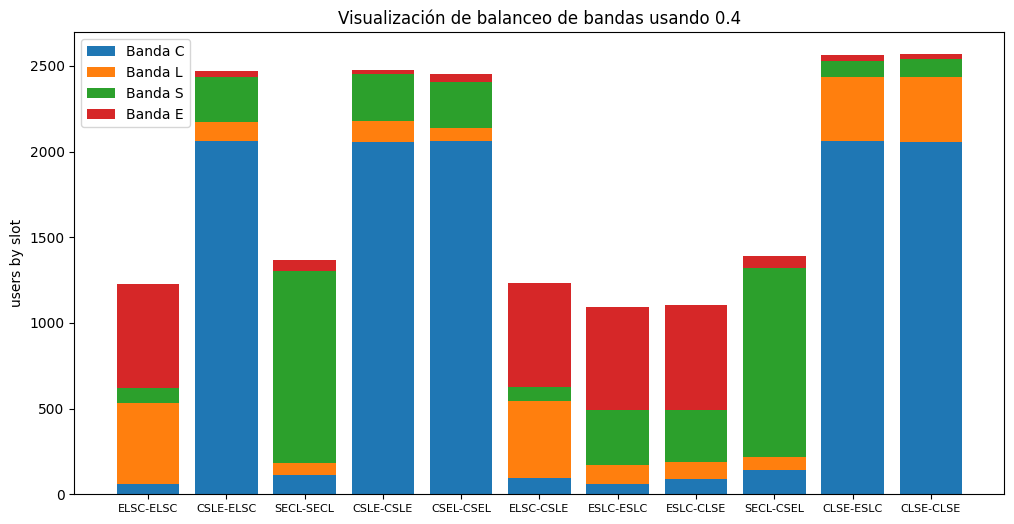

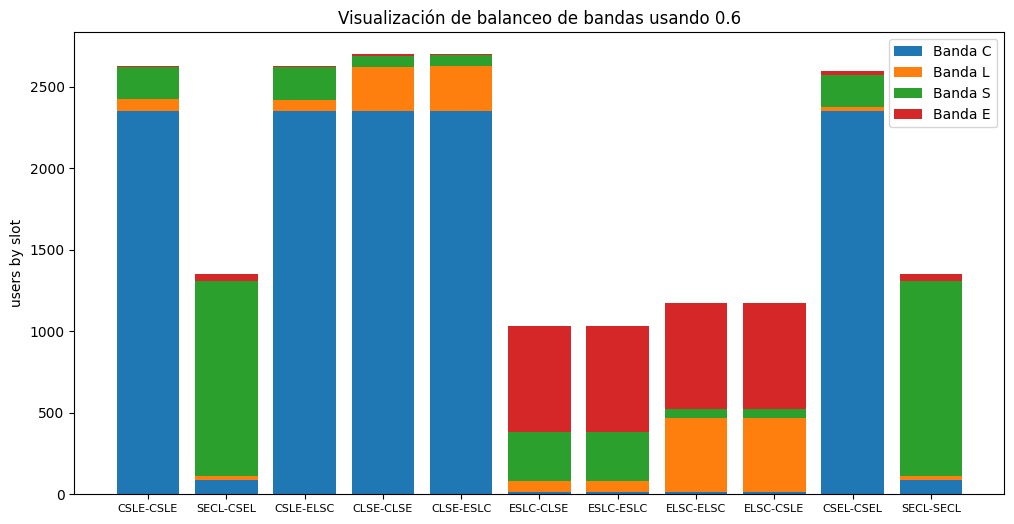

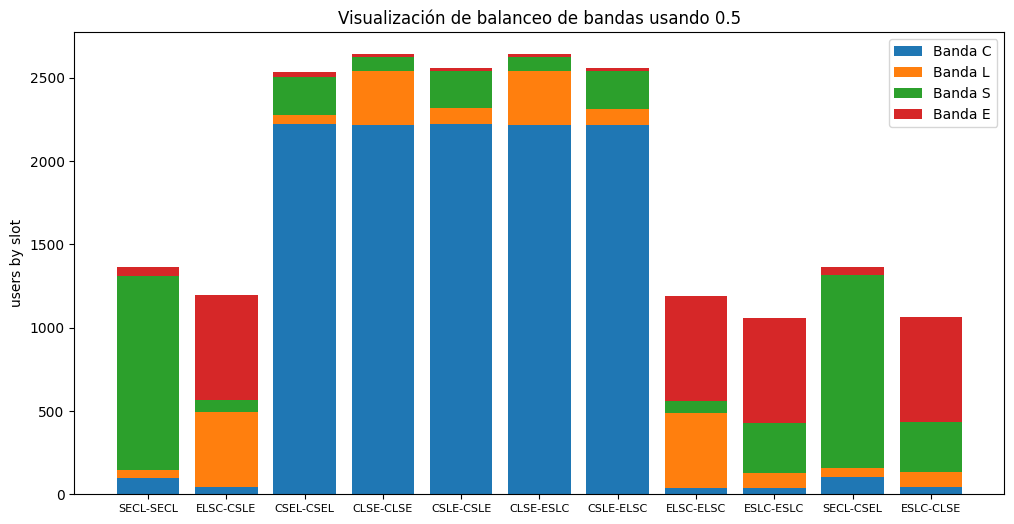

In [24]:
import matplotlib.pyplot as plt
import numpy as np

for key, data in idata.items():
    # if key != "0.3":
    #     continue
    categorias = []
    # Datos: cada lista representa un tipo de mesa por categoría
    C = []
    S = []
    L = []
    E = []
    for order_key, order_data in data.items():
        categorias.append(order_key)
        for band, bandData in order_data.items():
            if band == "C":
                C.append(bandData)
            elif band == "S":
                S.append(bandData)
            elif band == "L":
                L.append(bandData)
            elif band == "E":
                E.append(bandData)

    # Posiciones en el eje X
    x = np.arange(len(categorias))
    plt.figure(figsize=(12, 6))
    # Crear barras apiladas
    plt.bar(x, C, label="Banda C")
    plt.bar(x, L, bottom=C, label="Banda L")
    plt.bar(x, S, bottom=np.array(C) + np.array(L), label="Banda S")
    plt.bar(x, E, bottom=np.array(C) + np.array(L) + np.array(S), label="Banda E")

    # Etiquetas y formato
    plt.xticks(x, categorias, fontsize=8)
    plt.ylabel("users by slot")
    plt.title(f"Visualización de balanceo de bandas usando {key}")
    plt.legend()

    # Mostrar gráfico
    plt.show()

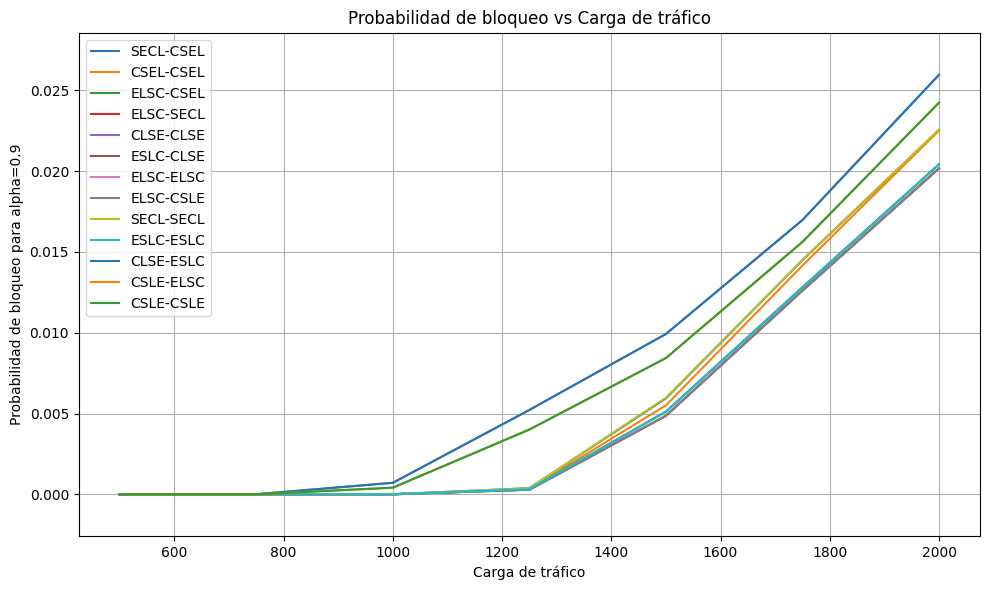

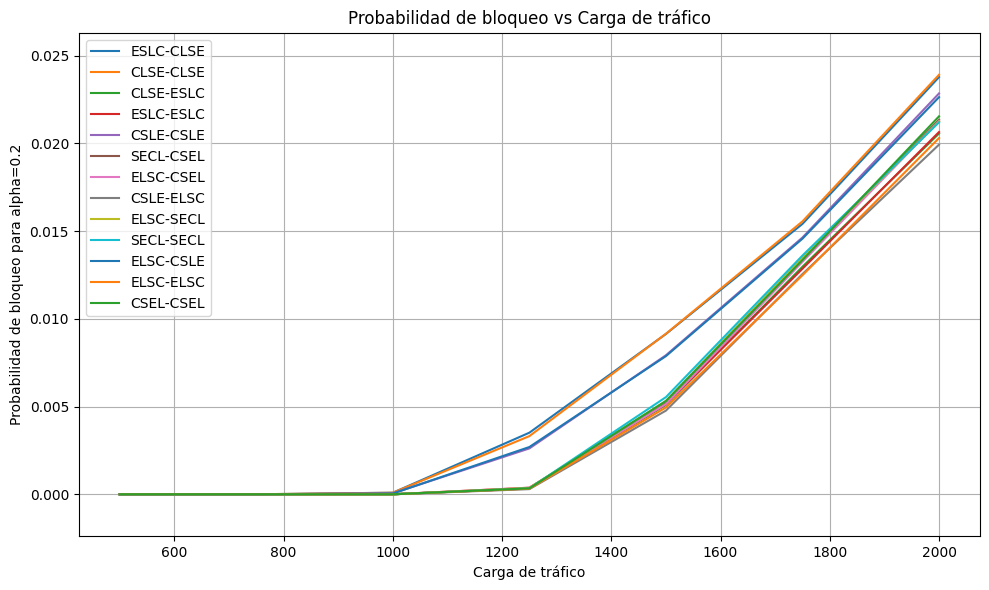

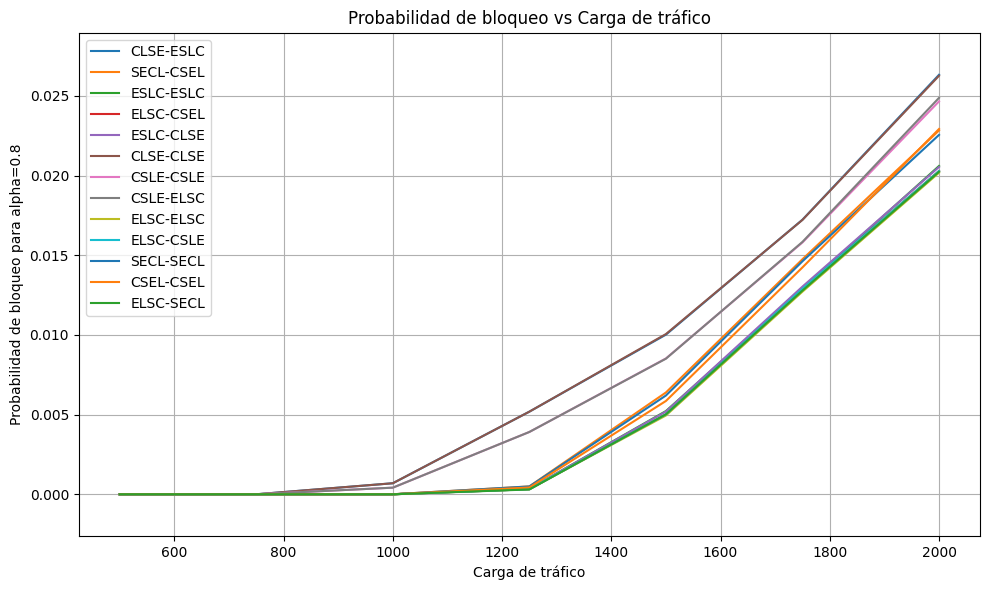

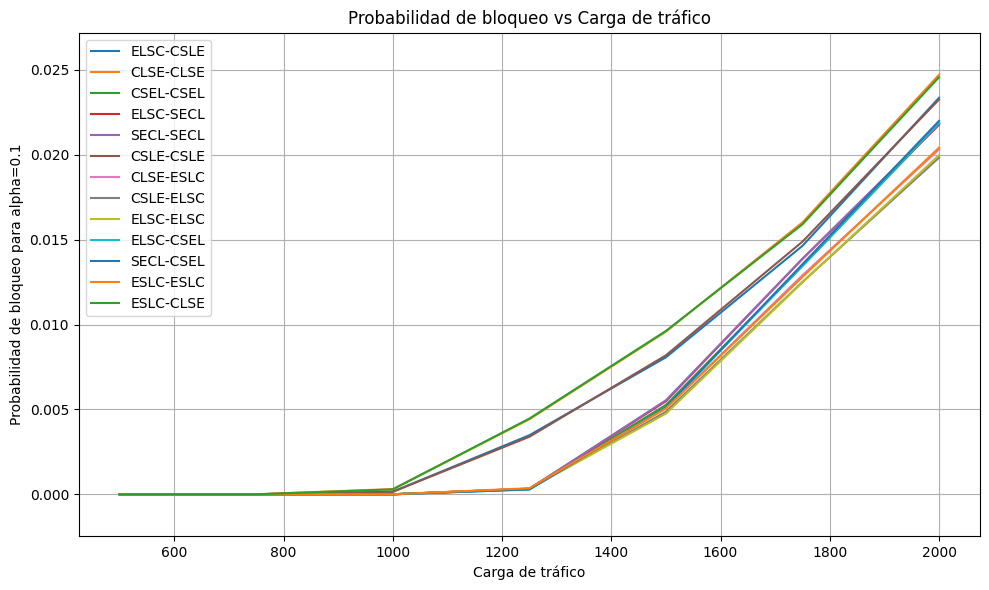

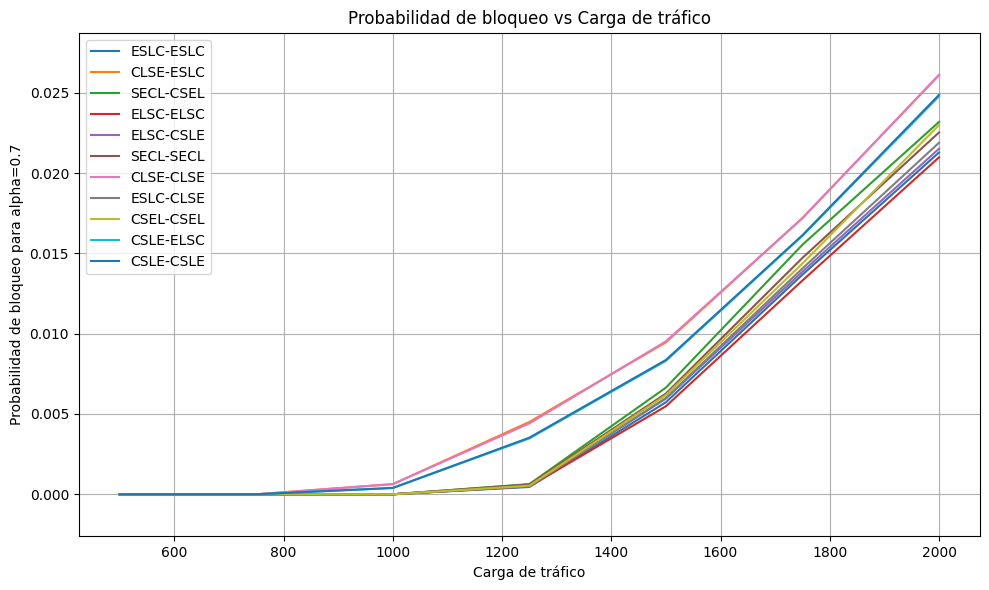

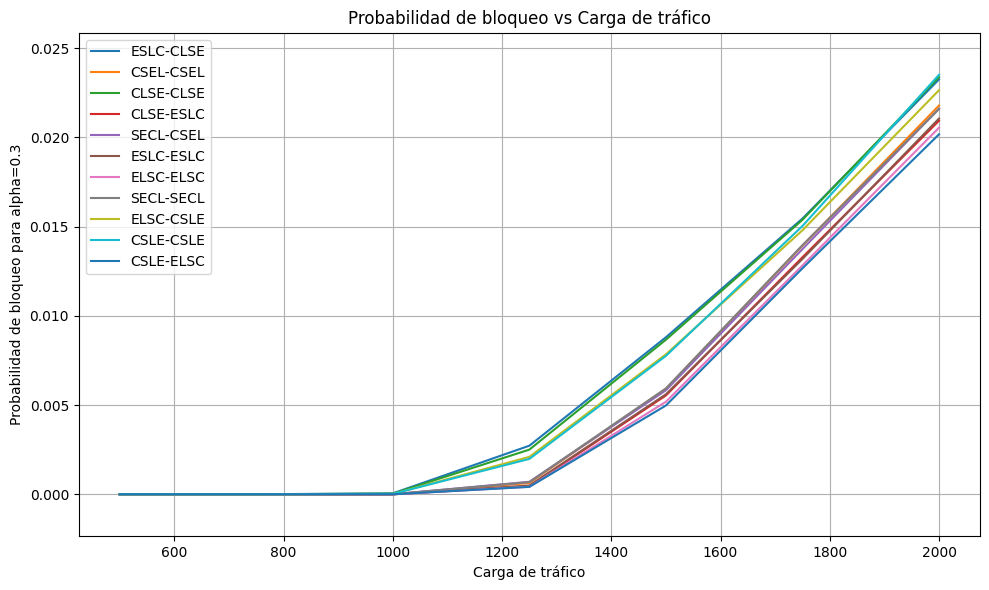

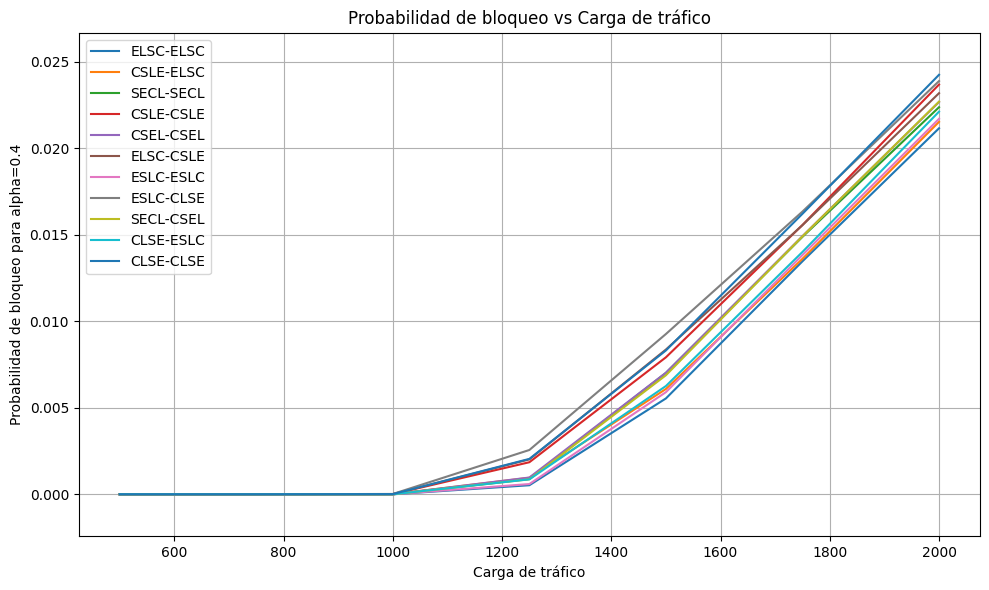

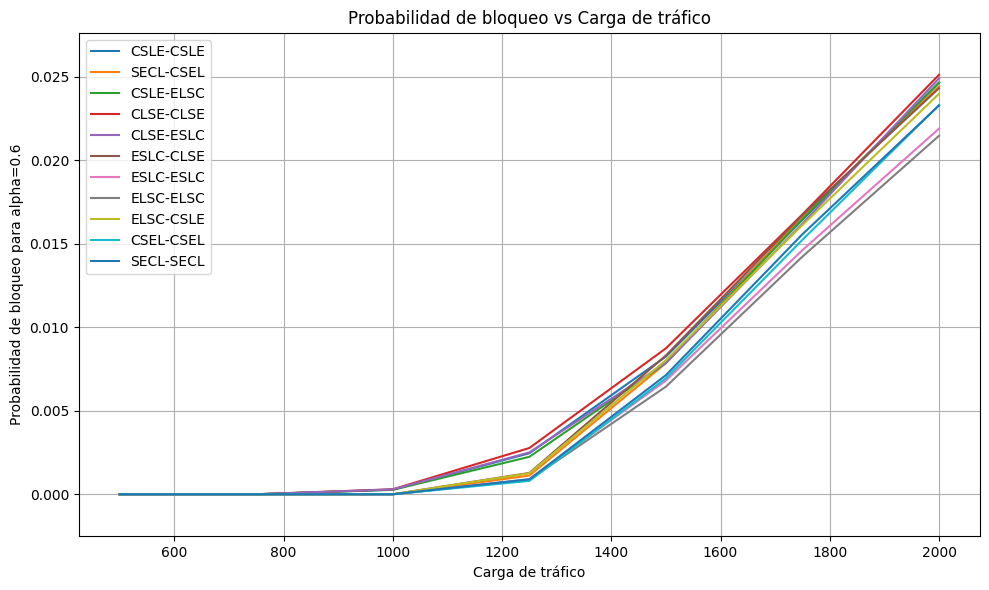

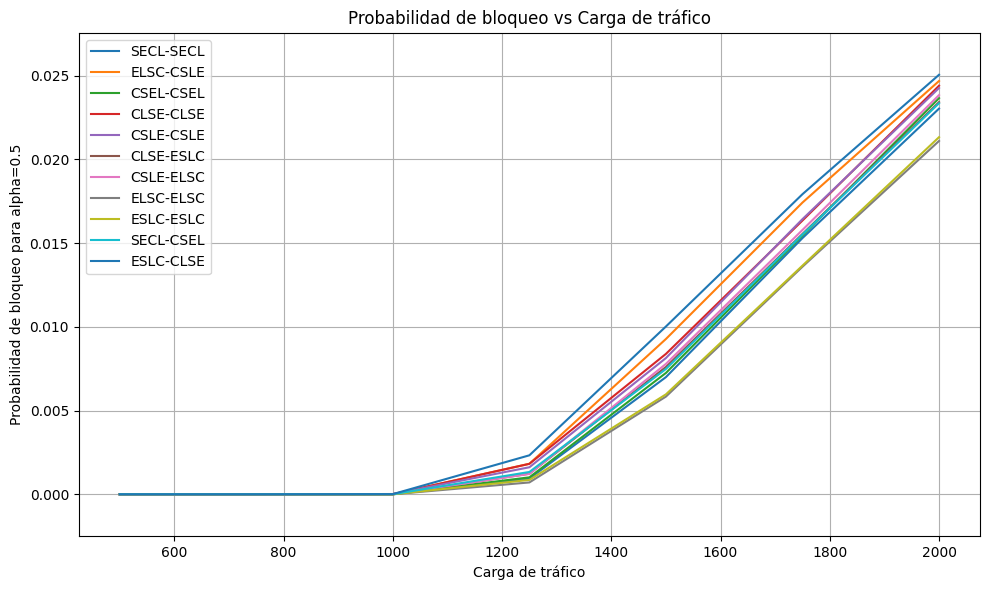

In [25]:
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    # key = "0.3"
    # data = results["0.3"]

    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Probabilidad de bloqueo vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Sacando mejor y peor


In [ ]:
# Diferencia porcentual
import matplotlib.pyplot as plt
import numpy as np


block_prob: dict[str, list[tuple[str, float]]] = {}
valores = {}
ordenes = {}

for key, data in results.items():
    valores[key] = {}
    ordenes[key] = {}
    # key = "0.3"
    # data = results["0.3"]
    # print(key, data)
    # plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        if order_key == "ELSC-SECL" or order_key == "ELSC-CSEL":
            continue
        valor_clse = results["1.0"]["CLSE-CLSE"]
        pb = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in valor_clse
        ]
        pb_ordenados = sorted(pb, key=lambda p: p[0])
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        for ind, ((pb_x, pb_y), (pa_x, pa_y)) in enumerate(
            zip(pb_ordenados, pares_ordenados)
        ):
            if pb_y == 0:
                pares_ordenados[ind] = (pa_x, 0)
            else:
                pares_ordenados[ind] = (pa_x, (pa_y - pb_y) * 100 / pb_y)
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        for traffic, value in zip(eje_x, eje_y):
            if traffic not in valores[key]:
                valores[key][traffic] = []
                ordenes[key][traffic] = []
            valores[key][traffic].append(value)
            ordenes[key][traffic].append(order_key)


# if order_key == "ESLC-ESLC":

test = 2000.0
alpha = "0.8"
print(alpha)
print(np.argmax(valores[alpha][test]))
print(ordenes[alpha][test][np.argmax(valores[alpha][test])])
# plt.plot(eje_x, eje_y, label=order_key)

0.8
0
CLSE-ESLC
